# Data Visualization with Matplotlib and Seaborn


This lesson introduces the most common charts used in Exploratory Data Analysis (EDA).

For each chart, we will learn:

1. **What the chart shows**
2. **When to use it**
3. **Which variables it requires**
4. **How to create it**
5. **How to interpret it**

> The purpose of visualization is not decoration.  
> Every chart should answer a clear analytical question.

## Learning Outcomes

By the end of this lesson, students should be able to:

- Explain the difference between Matplotlib and Seaborn.
- Select an appropriate chart for a data-analysis question.
- Create basic charts using both libraries.
- Add titles, labels, legends, and figure sizes.
- Interpret distributions, comparisons, relationships, and correlations.
- Avoid common visualization mistakes.

# 1. Matplotlib vs Seaborn

| Library | Main Role | Best Used For |
|---|---|---|
| **Matplotlib** | The core Python plotting library | Full control over figures, axes, labels, and chart elements |
| **Seaborn** | A higher-level library built on Matplotlib | Statistical charts and attractive plots from Pandas DataFrames |

### Simple rule

- Use **Seaborn** to create the main statistical chart.
- Use **Matplotlib** to control the figure size, title, labels, and final display.

## 2. Import the Libraries

In [1]:
# Import NumPy for generating numerical example data.
import numpy as np

# Import Pandas for creating and working with DataFrames.
import pandas as pd

# Import Matplotlib's pyplot module for creating and customizing charts.
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization.
import seaborn as sns

# Set a fixed random seed so the generated dataset is reproducible.
RANDOM_STATE = 42

# Create a NumPy random-number generator.
rng = np.random.default_rng(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Create a Simple Practice Dataset

We will use a small synthetic customer dataset containing:

- Customer age
- City
- Monthly spending
- Number of visits
- Satisfaction score
- Membership type
- Churn status
- Monthly sales values for a separate time-series example

In [2]:
# Define the number of customer records to generate.
n_customers = 220

# Create a DataFrame containing numerical and categorical features.
customers = pd.DataFrame({
    "age": rng.integers(18, 70, size=n_customers),
    "city": rng.choice(
        ["Riyadh", "Jeddah", "Dammam", "Tabuk"],
        size=n_customers,
        p=[0.45, 0.25, 0.20, 0.10]
    ),
    "monthly_spend": np.round(
        rng.gamma(shape=2.5, scale=90, size=n_customers),
        2
    ),
    "visits": rng.integers(1, 20, size=n_customers),
    "satisfaction": rng.integers(1, 6, size=n_customers),
    "membership": rng.choice(
        ["Basic", "Silver", "Gold"],
        size=n_customers,
        p=[0.50, 0.30, 0.20]
    ),
    "churn": rng.choice(
        ["No", "Yes"],
        size=n_customers,
        p=[0.82, 0.18]
    )
})

# Create a sequence of monthly dates for the line-chart example.
months = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

# Create a DataFrame containing monthly sales values.
monthly_sales = pd.DataFrame({
    "month": months,
    "sales": [120, 135, 128, 150, 165, 172, 168, 190, 205, 198, 220, 235]
})

# Display the first five customer records.
display(customers.head())

# Display the monthly sales dataset.
display(monthly_sales)

,age,city,monthly_spend,visits,satisfaction,membership,churn
0,22,Jeddah,357.67,18,3,Silver,No
1,58,Riyadh,318.09,19,4,Basic,Yes
2,52,Riyadh,204.48,2,3,Gold,No
3,40,Jeddah,312.35,7,5,Basic,No
4,40,Riyadh,308.72,14,2,Silver,Yes


,month,sales
0,2025-01-01,120
1,2025-02-01,135
2,2025-03-01,128
3,2025-04-01,150
4,2025-05-01,165
5,2025-06-01,172
6,2025-07-01,168
7,2025-08-01,190
8,2025-09-01,205
9,2025-10-01,198


# 4. The Basic Plotting Pattern

Most charts in this notebook follow the same pattern:

```python
plt.figure(figsize=(width, height))
sns.some_plot(data=df, x="column")
plt.title("Chart Title")
plt.xlabel("X-axis Label")
plt.ylabel("Y-axis Label")
plt.show()
```

### Function meanings

| Function | Purpose |
|---|---|
| `plt.figure()` | Creates a new figure and controls its size |
| `sns.some_plot()` | Creates the main chart |
| `plt.title()` | Adds a title |
| `plt.xlabel()` | Labels the x-axis |
| `plt.ylabel()` | Labels the y-axis |
| `plt.show()` | Displays the completed chart |

# 5. Line Plot

## What does it show?

A line plot shows how a numerical value changes across an ordered sequence, usually time.

## Use it when

- The x-axis represents time or another ordered variable.
- You want to identify trends, increases, decreases, or seasonal patterns.

## Variable types

- **X-axis:** Date, time, or ordered sequence
- **Y-axis:** Numerical variable

## Analytical question

> How did sales change from month to month?

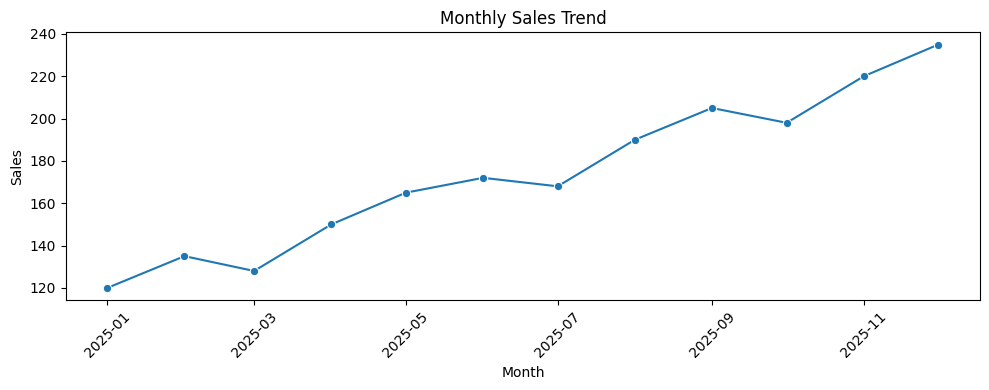

In [3]:
# Create a new figure with a readable width and height.
plt.figure(figsize=(10, 4))

# Draw a line chart showing monthly sales over time.
sns.lineplot(
    data=monthly_sales,
    x="month",
    y="sales",
    marker="o"
)

# Add a clear chart title.
plt.title("Monthly Sales Trend")

# Label the horizontal axis.
plt.xlabel("Month")

# Label the vertical axis.
plt.ylabel("Sales")

# Rotate date labels so they are easier to read.
plt.xticks(rotation=45)

# Adjust spacing to prevent labels from being cut off.
plt.tight_layout()

# Display the completed chart.
plt.show()

### How to interpret the line plot

Look for:

- Overall upward or downward trends
- Sudden increases or decreases
- Repeated patterns
- Unusual time periods

### Do not use it when

The x-axis contains unordered categories such as city names. A bar chart is usually better for categories.

# 6. Bar Plot

## What does it show?

A bar plot compares an aggregated numerical value across categories.

By default, `sns.barplot()` displays the **mean** of the numerical variable for each category.

## Use it when

- You want to compare an average or another summary across groups.
- One variable is categorical and the other is numerical.

## Variable types

- **X-axis:** Categorical variable
- **Y-axis:** Numerical variable

## Analytical question

> Which membership type has the highest average monthly spending?

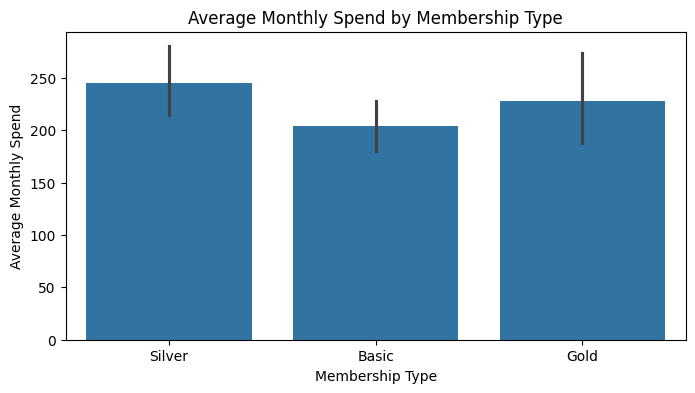

In [4]:
# Create a new figure for the bar chart.
plt.figure(figsize=(8, 4))

# Draw a bar chart comparing average spending across membership groups.
sns.barplot(
    data=customers,
    x="membership",
    y="monthly_spend"
)

# Add a descriptive title.
plt.title("Average Monthly Spend by Membership Type")

# Label the category axis.
plt.xlabel("Membership Type")

# Label the numerical axis.
plt.ylabel("Average Monthly Spend")

# Display the chart.
plt.show()

### Important distinction

- `sns.barplot()` summarizes a numerical value, usually using the mean.
- `sns.countplot()` counts how many records belong to each category.

Do not confuse the two.

# 7. Count Plot

## What does it show?

A count plot displays the number of observations in each category.

## Use it when

- You want to examine category frequencies.
- You want to check class balance.
- You do not need a numerical y-variable.

## Variable types

- **X-axis:** One categorical variable
- **Y-axis:** Automatically calculated count

## Analytical question

> How many customers belong to each membership type?

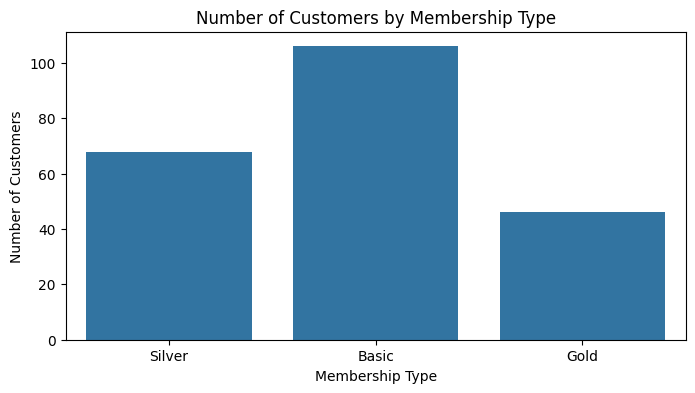

In [ ]:
# Create a new figure for the count plot.
plt.figure(figsize=(8, 4))

# Count and display the number of customers in each membership category.
sns.countplot(
    data=customers,
    x="membership"
)

# Add a chart title.
plt.title("Number of Customers by Membership Type")

# Label the horizontal axis.
plt.xlabel("Membership Type")

# Label the vertical axis.
plt.ylabel("Number of Customers")

# Display the chart.
plt.show()

## Count Plot with `hue`

The `hue` parameter divides each category into additional subgroups.

### Analytical question

> How is churn distributed within each membership type?

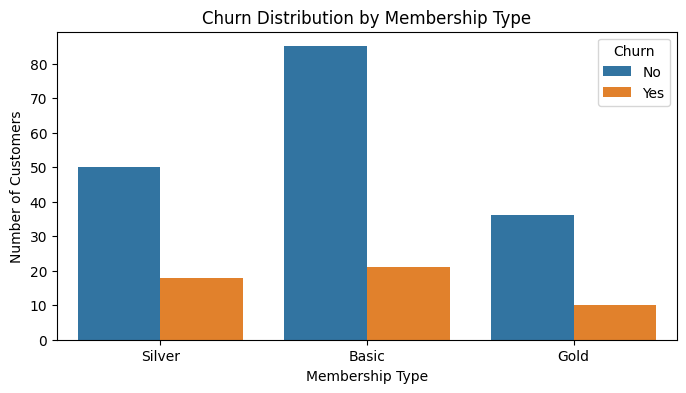

In [ ]:
# Create a new figure for a grouped count plot.
plt.figure(figsize=(8, 4))

# Count membership categories and separate each bar by churn status.
sns.countplot(
    data=customers,
    x="membership",
    hue="churn"
)

# Add a chart title.
plt.title("Churn Distribution by Membership Type")

# Label the horizontal axis.
plt.xlabel("Membership Type")

# Label the vertical axis.
plt.ylabel("Number of Customers")

# Add a title to the automatically generated legend.
plt.legend(title="Churn")

# Display the chart.
plt.show()

# 8. Histogram

## What does it show?

A histogram divides a numerical variable into intervals called **bins** and counts how many observations fall inside each interval.

## Use it when

- You want to understand the shape of a numerical distribution.
- You want to identify skewness, multiple peaks, gaps, or long tails.

## Variable types

- **X-axis:** One numerical variable
- **Y-axis:** Frequency or count

## Analytical question

> How is monthly spending distributed?

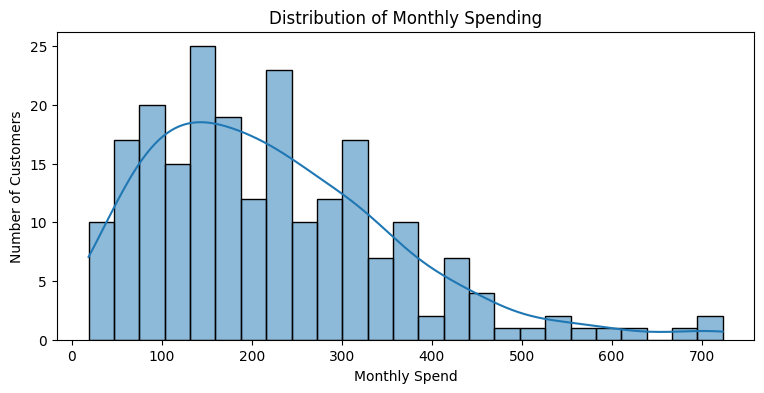

In [ ]:
# Create a new figure for the histogram.
plt.figure(figsize=(9, 4))

# Draw a histogram and add a smooth density curve using kde=True.
sns.histplot(
    data=customers,
    x="monthly_spend",
    bins=25,
    kde=True
)

# Add a descriptive title.
plt.title("Distribution of Monthly Spending")

# Label the numerical axis.
plt.xlabel("Monthly Spend")

# Label the frequency axis.
plt.ylabel("Number of Customers")

# Display the chart.
plt.show()

### How to interpret a histogram

Look for:

- **Symmetry:** Both sides have a similar shape.
- **Right skew:** A long tail extends toward larger values.
- **Left skew:** A long tail extends toward smaller values.
- **Multiple peaks:** Different subgroups may exist.
- **Gaps:** Some value ranges have few or no observations.

### The `bins` parameter

- Too few bins hide details.
- Too many bins make the chart noisy.
- Try several reasonable values before making a conclusion.

# 9. KDE Plot

## What does it show?

A KDE plot creates a smooth estimate of a numerical distribution.

KDE stands for **Kernel Density Estimation**.

## Use it when

- You want a smooth view of distribution shape.
- You want to compare distributions between groups.

## Variable types

- **X-axis:** One numerical variable
- **Y-axis:** Estimated density

## Analytical question

> How does spending distribution differ between churned and retained customers?

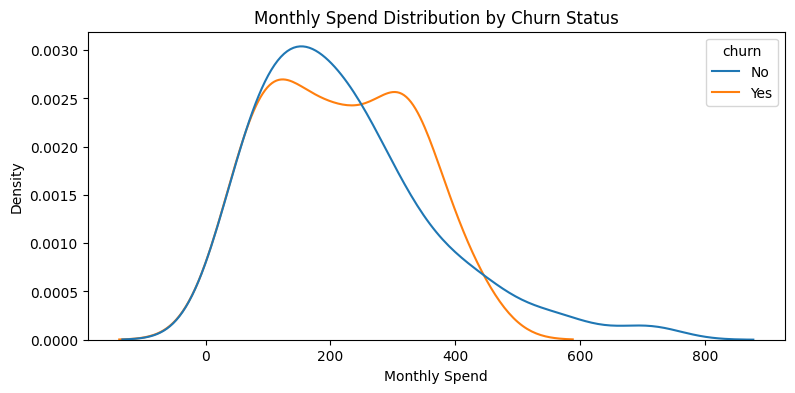

In [ ]:
# Create a new figure for the KDE plot.
plt.figure(figsize=(9, 4))

# Draw separate smooth spending distributions using churn as the subgroup.
sns.kdeplot(
    data=customers,
    x="monthly_spend",
    hue="churn",
    common_norm=False
)

# Add a descriptive title.
plt.title("Monthly Spend Distribution by Churn Status")

# Label the horizontal axis.
plt.xlabel("Monthly Spend")

# Label the vertical axis.
plt.ylabel("Density")

# Display the chart.
plt.show()

### Beginner caution

A KDE curve is an estimate, not a direct count. For beginners, it is often useful to view the histogram first and then use KDE as an additional summary.

# 10. Box Plot

## What does it show?

A box plot summarizes a numerical distribution using:

- Median
- Lower and upper quartiles
- Interquartile range
- Potential outliers

## Use it when

- You want to detect possible outliers.
- You want to compare numerical distributions across groups.

## Variable types

- **X-axis:** Optional categorical variable
- **Y-axis:** Numerical variable

## Analytical question

> Does monthly spending differ across membership types?

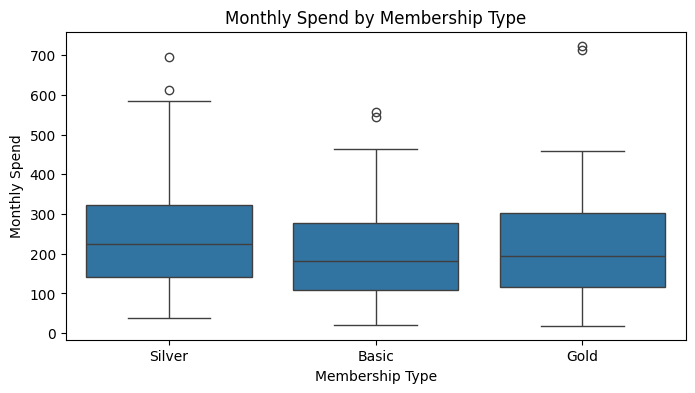

In [ ]:
# Create a new figure for the grouped box plot.
plt.figure(figsize=(8, 4))

# Draw a box plot comparing spending distributions across membership types.
sns.boxplot(
    data=customers,
    x="membership",
    y="monthly_spend"
)

# Add a chart title.
plt.title("Monthly Spend by Membership Type")

# Label the category axis.
plt.xlabel("Membership Type")

# Label the numerical axis.
plt.ylabel("Monthly Spend")

# Display the chart.
plt.show()

### How to interpret a box plot

- The line inside the box is the **median**.
- The box contains the middle 50% of values.
- The whiskers show the typical range.
- Points beyond the whiskers are potential outliers.

> A point outside the whiskers is not automatically an error. It may be a valid rare observation.

# 11. Violin Plot

## What does it show?

A violin plot combines:

- The summary information of a box plot
- The distribution shape of a KDE plot

## Use it when

- You want to compare the full shape of numerical distributions across categories.
- A box plot does not show enough detail.

## Analytical question

> How does the full spending distribution differ across membership types?

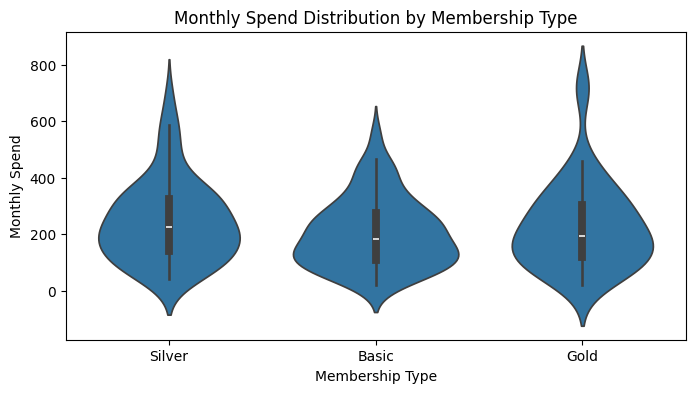

In [ ]:
# Create a new figure for the violin plot.
plt.figure(figsize=(8, 4))

# Draw a violin plot showing distribution shape for each membership category.
sns.violinplot(
    data=customers,
    x="membership",
    y="monthly_spend"
)

# Add a chart title.
plt.title("Monthly Spend Distribution by Membership Type")

# Label the horizontal axis.
plt.xlabel("Membership Type")

# Label the vertical axis.
plt.ylabel("Monthly Spend")

# Display the chart.
plt.show()

### Box plot vs violin plot

| Box Plot | Violin Plot |
|---|---|
| Easier for beginners | Shows more distribution detail |
| Clearly shows median and quartiles | Clearly shows density and shape |
| Better for simple summaries | Better for comparing distribution shapes |

# 12. Scatter Plot

## What does it show?

A scatter plot displays the relationship between two numerical variables.

Each point represents one observation.

## Use it when

- Both variables are numerical.
- You want to identify relationships, clusters, trends, or outliers.

## Variable types

- **X-axis:** Numerical variable
- **Y-axis:** Numerical variable

## Analytical question

> Is there a relationship between customer visits and monthly spending?

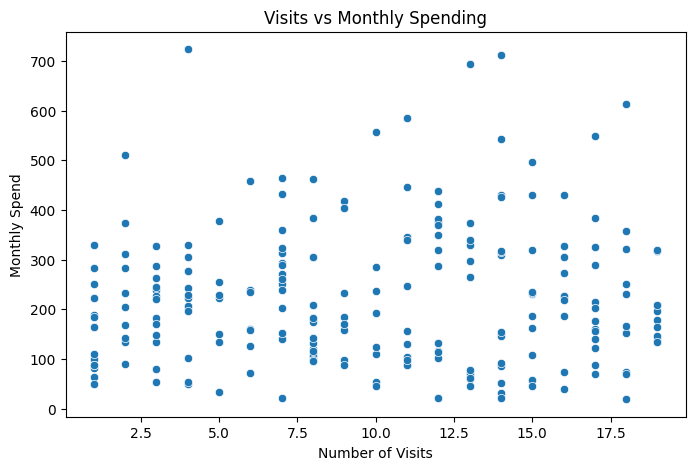

In [ ]:
# Create a new figure for the scatter plot.
plt.figure(figsize=(8, 5))

# Draw one point per customer using visits and monthly spending.
sns.scatterplot(
    data=customers,
    x="visits",
    y="monthly_spend"
)

# Add a descriptive title.
plt.title("Visits vs Monthly Spending")

# Label the horizontal axis.
plt.xlabel("Number of Visits")

# Label the vertical axis.
plt.ylabel("Monthly Spend")

# Display the chart.
plt.show()

## Scatter Plot with `hue`

A categorical variable can be added through `hue` to identify subgroups.

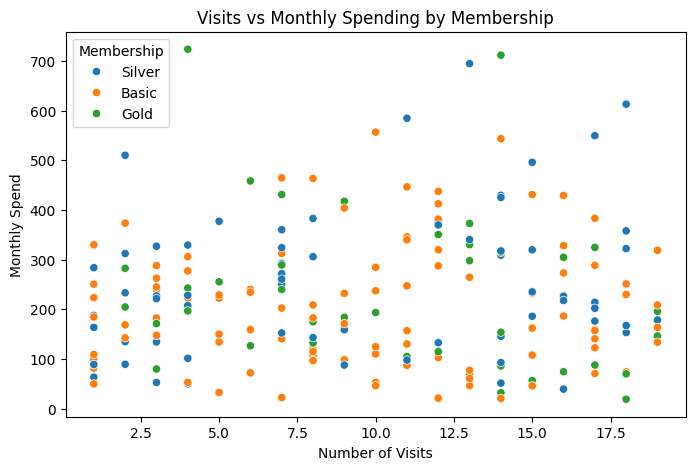

In [ ]:
# Create a new figure for the grouped scatter plot.
plt.figure(figsize=(8, 5))

# Draw the numerical relationship and identify membership groups using hue.
sns.scatterplot(
    data=customers,
    x="visits",
    y="monthly_spend",
    hue="membership"
)

# Add a title.
plt.title("Visits vs Monthly Spending by Membership")

# Label the horizontal axis.
plt.xlabel("Number of Visits")

# Label the vertical axis.
plt.ylabel("Monthly Spend")

# Add a title to the legend.
plt.legend(title="Membership")

# Display the chart.
plt.show()

### How to interpret a scatter plot

Look for:

- **Positive relationship:** Y tends to increase as X increases.
- **Negative relationship:** Y tends to decrease as X increases.
- **No clear relationship:** Points appear randomly distributed.
- **Clusters:** Groups of similar observations.
- **Outliers:** Isolated points far from the rest.

A visual relationship does not prove causation.

# 13. Regression Plot

## What does it show?

A regression plot combines a scatter plot with a fitted linear trend line.

## Use it when

- Both variables are numerical.
- You want to see whether a linear trend may exist.

## Analytical question

> Is monthly spending approximately related to the number of visits?

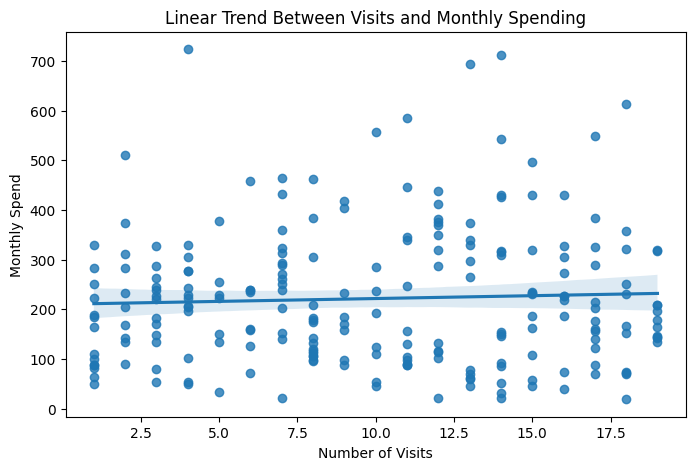

In [ ]:
# Create a new figure for the regression plot.
plt.figure(figsize=(8, 5))

# Draw a scatter plot and fit a linear regression trend line.
sns.regplot(
    data=customers,
    x="visits",
    y="monthly_spend"
)

# Add a title.
plt.title("Linear Trend Between Visits and Monthly Spending")

# Label the horizontal axis.
plt.xlabel("Number of Visits")

# Label the vertical axis.
plt.ylabel("Monthly Spend")

# Display the chart.
plt.show()

### Important caution

The trend line summarizes a linear pattern. It does not prove:

- Causation
- Statistical significance
- That a linear model is the best model

Further statistical analysis is required.

# 14. Heatmap

## What does it show?

A heatmap represents numerical values using a matrix of shaded cells.

In EDA, it is commonly used to display a **correlation matrix**.

## Use it when

- You want to compare correlations among several numerical variables.
- You want to identify strong positive or negative relationships.
- You want to detect possible multicollinearity.

## Analytical question

> Which numerical variables are most strongly related?

In [ ]:
# Select only the numerical columns required for correlation analysis.
numeric_columns = customers[
    ["age", "monthly_spend", "visits", "satisfaction"]
]

# Calculate pairwise linear correlations between numerical columns.
correlation_matrix = numeric_columns.corr()

# Display the correlation values as a table.
display(correlation_matrix)

,age,monthly_spend,visits,satisfaction
age,1.000000,-0.047281,0.017806,-0.008253
monthly_spend,-0.047281,1.000000,0.046188,-0.006641
visits,0.017806,0.046188,1.000000,0.026130
satisfaction,-0.008253,-0.006641,0.026130,1.000000


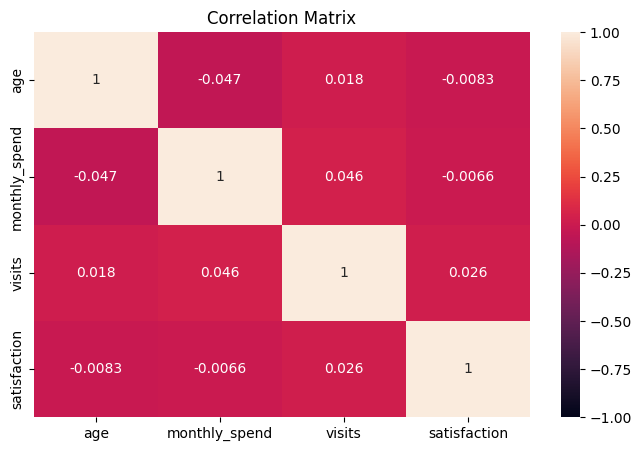

In [ ]:
# Create a new figure for the correlation heatmap.
plt.figure(figsize=(8, 5))

# Draw the correlation matrix and write each value inside its cell.
sns.heatmap(
    correlation_matrix,
    annot=True,
    vmin=-1,
    vmax=1
)

# Add a descriptive title.
plt.title("Correlation Matrix")

# Display the chart.
plt.show()

### Interpreting correlation values

| Correlation | Meaning |
|---|---|
| Close to `+1` | Strong positive linear relationship |
| Close to `0` | Weak or no linear relationship |
| Close to `-1` | Strong negative linear relationship |

### Important caution

- Correlation measures linear association.
- Correlation does not imply causation.
- A low correlation does not prove that no non-linear relationship exists.

# 15. Pie Chart with Matplotlib

## What does it show?

A pie chart displays category proportions as parts of a circle.

## Use it when

- There are only a few categories.
- The categories form a complete whole.
- The differences between proportions are easy to see.

## Analytical question

> What proportion of customers churned?

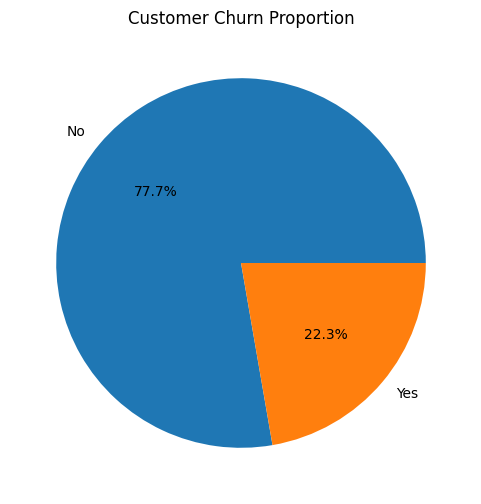

In [ ]:
# Count the number of customers in each churn category.
churn_counts = customers["churn"].value_counts()

# Create a new figure for the pie chart.
plt.figure(figsize=(6, 6))

# Draw the pie chart using category counts and display percentages.
plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%"
)

# Add a chart title.
plt.title("Customer Churn Proportion")

# Display the chart.
plt.show()

### Pie chart caution

Pie charts become difficult to compare when:

- There are many categories.
- Category proportions are similar.
- Precise comparison is required.

A bar chart or count plot is often clearer.

# 16. Basic Matplotlib Customization

These functions can be used with Seaborn or Matplotlib charts.

| Function | Purpose |
|---|---|
| `plt.figure(figsize=(w, h))` | Controls chart size |
| `plt.title()` | Adds a title |
| `plt.xlabel()` | Labels the x-axis |
| `plt.ylabel()` | Labels the y-axis |
| `plt.xticks(rotation=...)` | Rotates x-axis labels |
| `plt.legend()` | Controls the legend |
| `plt.xlim()` | Sets x-axis limits |
| `plt.ylim()` | Sets y-axis limits |
| `plt.tight_layout()` | Prevents label overlap |
| `plt.show()` | Displays the chart |

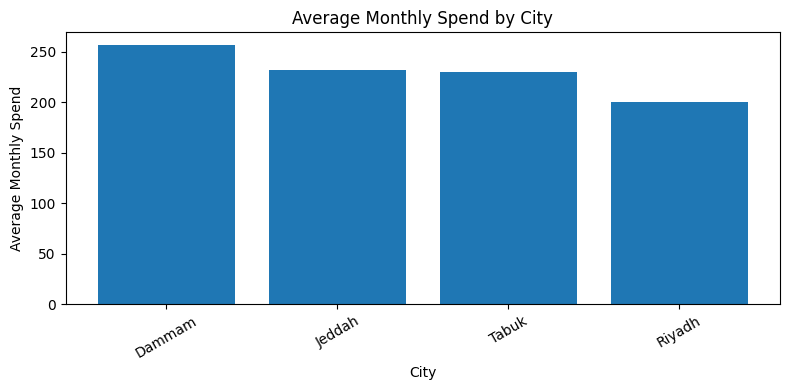

In [ ]:
# Calculate average spending for each city.
city_spend = (
    customers.groupby("city")["monthly_spend"]
    .mean()
    .sort_values(ascending=False)
)

# Create a new Matplotlib figure.
plt.figure(figsize=(8, 4))

# Draw a Matplotlib bar chart using the grouped city summary.
plt.bar(
    city_spend.index,
    city_spend.values
)

# Add a clear title.
plt.title("Average Monthly Spend by City")

# Label the x-axis.
plt.xlabel("City")

# Label the y-axis.
plt.ylabel("Average Monthly Spend")

# Rotate category labels slightly for readability.
plt.xticks(rotation=30)

# Start the y-axis at zero.
plt.ylim(bottom=0)

# Adjust spacing around the chart.
plt.tight_layout()

# Display the chart.
plt.show()

# 17. Chart Selection Guide

| Analytical Question | Variable Types | Recommended Chart |
|---|---|---|
| How does a value change over time? | Time + Numeric | Line plot |
| What is the average value by category? | Categorical + Numeric | Bar plot |
| How many records are in each category? | Categorical | Count plot |
| How is one numerical variable distributed? | Numeric | Histogram |
| What is the smooth distribution shape? | Numeric | KDE plot |
| Are there outliers? | Numeric | Box plot |
| How do distributions differ across groups? | Categorical + Numeric | Box or violin plot |
| Are two numerical variables related? | Numeric + Numeric | Scatter plot |
| Is there a possible linear trend? | Numeric + Numeric | Regression plot |
| How are several numerical variables correlated? | Multiple numeric variables | Heatmap |
| What proportion belongs to each category? | Few categorical groups | Pie chart |

# 18. Common Visualization Mistakes

## Mistake 1: Choosing the wrong chart

Using a line chart for unordered categories may falsely suggest a sequence.

## Mistake 2: Missing labels

A chart without a title or axis labels is difficult to interpret.

## Mistake 3: Too many categories

Crowded charts become unreadable. Consider grouping rare categories.

## Mistake 4: Using a pie chart with many slices

Use a bar chart instead.

## Mistake 5: Assuming correlation means causation

A relationship between variables does not prove that one causes the other.

## Mistake 6: Hiding outliers without investigation

Unusual observations may contain important information.

## Mistake 7: Creating a chart without a question

Before plotting, write the question the chart should answer.

# 19. Mini Practice Activity

Use the `customers` DataFrame to complete the following tasks.

### Task 1

Create a histogram of customer age.

### Task 2

Create a count plot showing the number of customers in each city.

### Task 3

Create a box plot comparing monthly spending by churn status.

### Task 4

Create a scatter plot showing age versus monthly spending.

### Task 5

Add `membership` as `hue` to the scatter plot.

### Task 6

Write one sentence interpreting each chart.

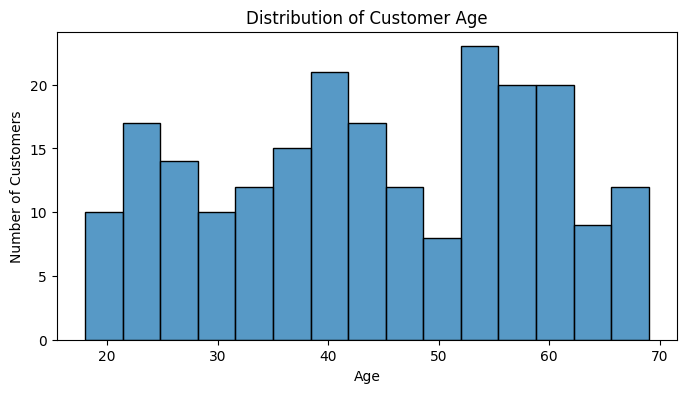

In [ ]:
# Task 1: Create a histogram of customer age.

# TODO: Create a new figure.

# TODO: Use sns.histplot() with the age column.

# TODO: Add a title and axis labels.

# TODO: Display the chart.

plt.figure(figsize=(8, 4))

sns.histplot(
    data=customers,
    x="age",
    bins=15
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

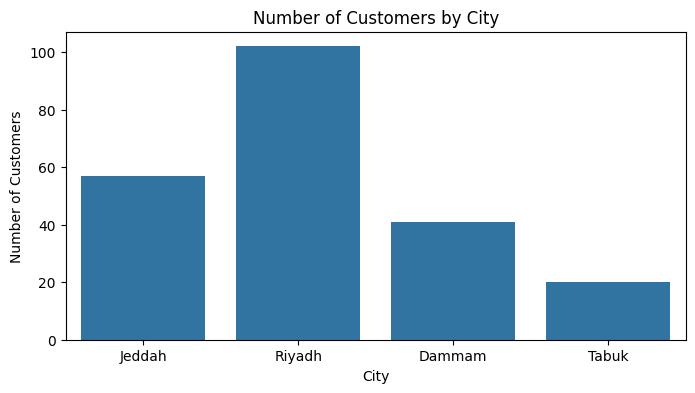

In [ ]:
# Task 2: Create a count plot for customer city.

# TODO: Create a new figure.

# TODO: Use sns.countplot() with the city column.

# TODO: Add a title and axis labels.

# TODO: Display the chart.
plt.figure(figsize=(8, 4))

sns.countplot(
    data=customers,
    x="city"
)

plt.title("Number of Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.show()

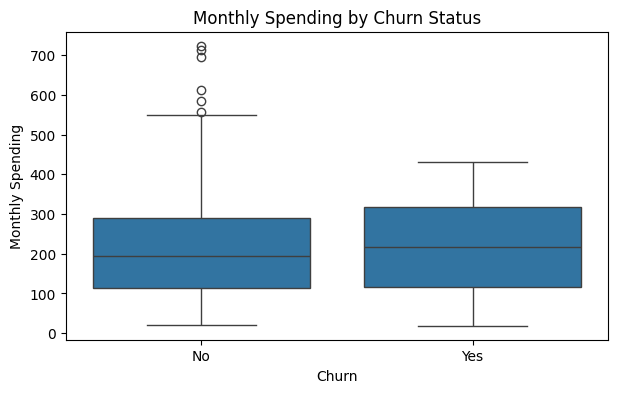

In [ ]:
# Task 3: Compare monthly spending by churn status with a box plot.

# TODO: Create a new figure.

# TODO: Use sns.boxplot() with churn and monthly_spend.

# TODO: Add a title and axis labels.

# TODO: Display the chart.
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=customers,
    x="churn",
    y="monthly_spend"
)

plt.title("Monthly Spending by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Spending")

plt.show()

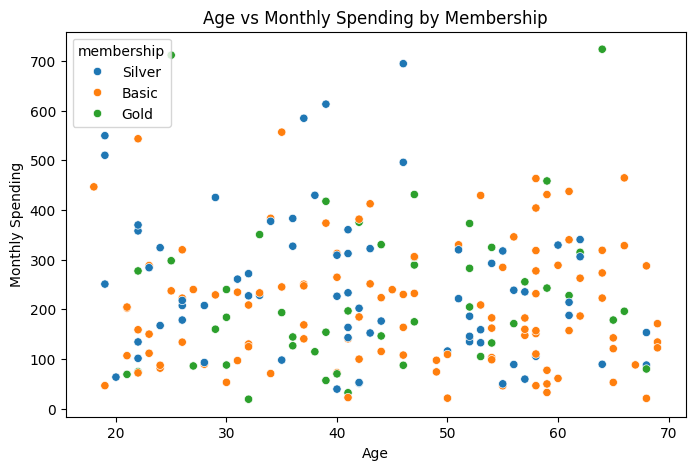

In [ ]:
# Task 4 and Task 5: Create an age-versus-spending scatter plot.

# TODO: Create a new figure.

# TODO: Use sns.scatterplot() with age and monthly_spend.

# TODO: Add membership as the hue variable.

# TODO: Add a title and axis labels.

# TODO: Display the chart.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=customers,
    x="age",
    y="monthly_spend",
    hue="membership"
)

plt.title("Age vs Monthly Spending by Membership")
plt.xlabel("Age")
plt.ylabel("Monthly Spending")

plt.show()

# 20. Suggested Solutions

In [ ]:
# Solution 1: Display the distribution of customer age.
plt.figure(figsize=(8, 4))
sns.histplot(data=customers, x="age", bins=15)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Solution 2: Count customers in each city.
plt.figure(figsize=(8, 4))
sns.countplot(data=customers, x="city")
plt.title("Number of Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Solution 3: Compare spending distributions for churn groups.
plt.figure(figsize=(7, 4))
sns.boxplot(data=customers, x="churn", y="monthly_spend")
plt.title("Monthly Spending by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Spend")
plt.show()

In [ ]:
# Solution 4 and 5: Explore age, spending, and membership together.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=customers,
    x="age",
    y="monthly_spend",
    hue="membership"
)
plt.title("Age vs Monthly Spending by Membership")
plt.xlabel("Age")
plt.ylabel("Monthly Spend")
plt.legend(title="Membership")
plt.show()

# 21. Final Summary

| Plot | Best Use |
|---|---|
| Line plot | Trends over time |
| Bar plot | Compare numerical summaries across categories |
| Count plot | Count categorical records |
| Histogram | Examine a numerical distribution |
| KDE plot | Examine a smooth distribution estimate |
| Box plot | Compare spread and identify possible outliers |
| Violin plot | Compare detailed distribution shapes |
| Scatter plot | Examine relationships between two numerical variables |
| Regression plot | Display a possible linear trend |
| Heatmap | Display a correlation matrix |
| Pie chart | Display simple proportions with few categories |

## Final rule

> Start with the analytical question, identify the variable types, and then choose the chart.